In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA = Path.home() / "Desktop/Classes/Smirnov_Research Project/defi-perps/drift/data/raw"

sol = pd.read_parquet(DATA / "SOL-PERP_funding_records.parquet")
btc = pd.read_parquet(DATA / "BTC-PERP_funding_records.parquet")
eth = pd.read_parquet(DATA / "ETH-PERP_funding_records.parquet")

df = pd.concat([sol, btc, eth], ignore_index=True)
df = df.sort_values(["market", "timestamp"]).reset_index(drop=True)

print(f"Total rows: {len(df):,}")
print(f"\nPer market:")
print(df.groupby("market")["timestamp"].agg(["count", "min", "max"]))

Total rows: 52,307

Per market:
          count                       min                       max
market                                                             
BTC-PERP  17417 2023-01-01 00:03:29+00:00 2024-12-31 23:00:04+00:00
ETH-PERP  17396 2023-01-01 00:00:00+00:00 2024-12-31 23:00:04+00:00
SOL-PERP  17494 2023-01-01 00:00:55+00:00 2024-12-31 23:00:04+00:00


In [5]:
# the central object: M_tk / Ī_tk
df["ratio"] = df["mark_twap"] / df["oracle_twap"]

print("Ratio M_tk / Ī_tk by market:")
print(df.groupby("market")["ratio"].describe().round(6))

Ratio M_tk / Ī_tk by market:
            count      mean       std       min       25%       50%       75%  \
market                                                                          
BTC-PERP  17417.0  1.000599  0.000979  0.991453  1.000034  1.000311  1.000830   
ETH-PERP  17396.0  1.000450  0.000879  0.994279  1.000000  1.000240  1.000726   
SOL-PERP  17494.0  1.000559  0.001072  0.993416  0.999988  1.000252  1.000855   

               max  
market              
BTC-PERP  1.012164  
ETH-PERP  1.013698  
SOL-PERP  1.020656  


In [6]:
SPLIT = pd.Timestamp("2024-01-01", tz="UTC")

train = df[df["timestamp"] < SPLIT].copy()
test  = df[df["timestamp"] >= SPLIT].copy()

print(f"Training (2023): {len(train):,} rows")
print(f"Test     (2024): {len(test):,} rows")
print(f"\nTraining per market:")
print(train.groupby("market")["timestamp"].count())
print(f"\nTest per market:")
print(test.groupby("market")["timestamp"].count())

Training (2023): 25,987 rows
Test     (2024): 26,320 rows

Training per market:
market
BTC-PERP    8643
ETH-PERP    8623
SOL-PERP    8721
Name: timestamp, dtype: int64

Test per market:
market
BTC-PERP    8774
ETH-PERP    8773
SOL-PERP    8773
Name: timestamp, dtype: int64


In [7]:
# Gamma = 99th percentile of |M_{t+1} - Ī_{t+1}| on training data
gammas = {}

for market, grp in train.groupby("market"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    
    # one-period ahead absolute basis
    basis = (grp["mark_twap"] - grp["oracle_twap"]).abs()
    
    gamma = basis.quantile(0.99)
    gammas[market] = gamma
    
    print(f"{market}:")
    print(f"  Gamma (99th pct) = {gamma:.6f} USD")
    print(f"  As % of oracle   = {gamma / grp['oracle_twap'].mean() * 100:.4f}%")
    print()

print("Gammas fixed for test window:", gammas)

BTC-PERP:
  Gamma (99th pct) = 176.290804 USD
  As % of oracle   = 0.6106%

ETH-PERP:
  Gamma (99th pct) = 7.816181 USD
  As % of oracle   = 0.4354%

SOL-PERP:
  Gamma (99th pct) = 0.423507 USD
  As % of oracle   = 1.4491%

Gammas fixed for test window: {'BTC-PERP': 176.29080376000064, 'ETH-PERP': 7.816181399999928, 'SOL-PERP': 0.42350679999999585}


In [8]:
kappa_S = 0.00018   # 1.8 bps spot fee
kappa_F = 0.0       # Drift maker rebate ~ 0
r       = 0.0       # simplified
r_C     = 0.0       # simplified

rows = []

for market, grp in test.groupby("market"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    gamma = gammas[market]
    
    gamma_norm = gamma / grp["oracle_twap"]
    funding    = grp["f_tk"].abs() * grp["rho_k"]
    
    L_tk = (1 - kappa_S) + funding - gamma_norm
    U_tk = (1 + kappa_S) - funding + gamma_norm
    
    grp["L_tk"]       = L_tk
    grp["U_tk"]       = U_tk
    grp["gamma_norm"] = gamma_norm
    grp["violation"]  = (grp["ratio"] < grp["L_tk"]) | (grp["ratio"] > grp["U_tk"])
    grp["band_width"] = grp["U_tk"] - grp["L_tk"]
    
    rows.append(grp)

test_out = pd.concat(rows, ignore_index=True)

cols = ["timestamp", "market", "ratio", "L_tk", "U_tk", "violation", "band_width"]
print("Sample rows:")
print(test_out[cols].head(6).to_string())

Sample rows:
                  timestamp    market     ratio      L_tk      U_tk  violation  band_width
0 2024-01-01 00:01:28+00:00  BTC-PERP  1.001837  0.995739  1.004261      False    0.008521
1 2024-01-01 01:00:27+00:00  BTC-PERP  1.002249  0.995763  1.004237      False    0.008473
2 2024-01-01 02:01:28+00:00  BTC-PERP  1.002400  0.995781  1.004219      False    0.008437
3 2024-01-01 03:01:28+00:00  BTC-PERP  1.002620  0.995793  1.004207      False    0.008414
4 2024-01-01 04:01:27+00:00  BTC-PERP  1.002687  0.995787  1.004213      False    0.008425
5 2024-01-01 05:01:27+00:00  BTC-PERP  1.002908  0.995789  1.004211      False    0.008422


In [9]:
print("=" * 60)
print("TEST 1 RESULTS — Ratio M_tk/Ī_tk inside no-arbitrage bounds")
print("=" * 60)

summary = []

for market, grp in test_out.groupby("market"):
    n_obs     = len(grp)
    n_viol    = grp["violation"].sum()
    viol_rate = n_viol / n_obs
    mean_width = grp["band_width"].mean()
    
    # violation magnitude
    viol_mag = np.where(
        grp["ratio"] < grp["L_tk"],
        grp["L_tk"] - grp["ratio"],
        np.where(grp["ratio"] > grp["U_tk"],
                 grp["ratio"] - grp["U_tk"], 0)
    )
    mean_mag = viol_mag[viol_mag > 0].mean() if n_viol > 0 else 0
    
    # violation duration
    runs, dur = [], 0
    for v in grp["violation"]:
        if v:
            dur += 1
        elif dur > 0:
            runs.append(dur)
            dur = 0
    if dur > 0:
        runs.append(dur)
    mean_dur = np.mean(runs) if runs else 0
    
    summary.append({
        "Market"          : market,
        "Obs"             : n_obs,
        "Violations"      : n_viol,
        "Violation rate"  : f"{viol_rate*100:.2f}%",
        "Mean magnitude"  : f"{mean_mag:.6f}",
        "Mean duration"   : f"{mean_dur:.1f} periods",
        "Mean band width" : f"{mean_width:.6f}",
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

TEST 1 RESULTS — Ratio M_tk/Ī_tk inside no-arbitrage bounds
  Market  Obs  Violations Violation rate Mean magnitude Mean duration Mean band width
BTC-PERP 8774         399          4.55%       0.000996   6.2 periods        0.005894
ETH-PERP 8773         282          3.21%       0.000967   5.6 periods        0.005585
SOL-PERP 8773         440          5.02%       0.000925   4.9 periods        0.006075


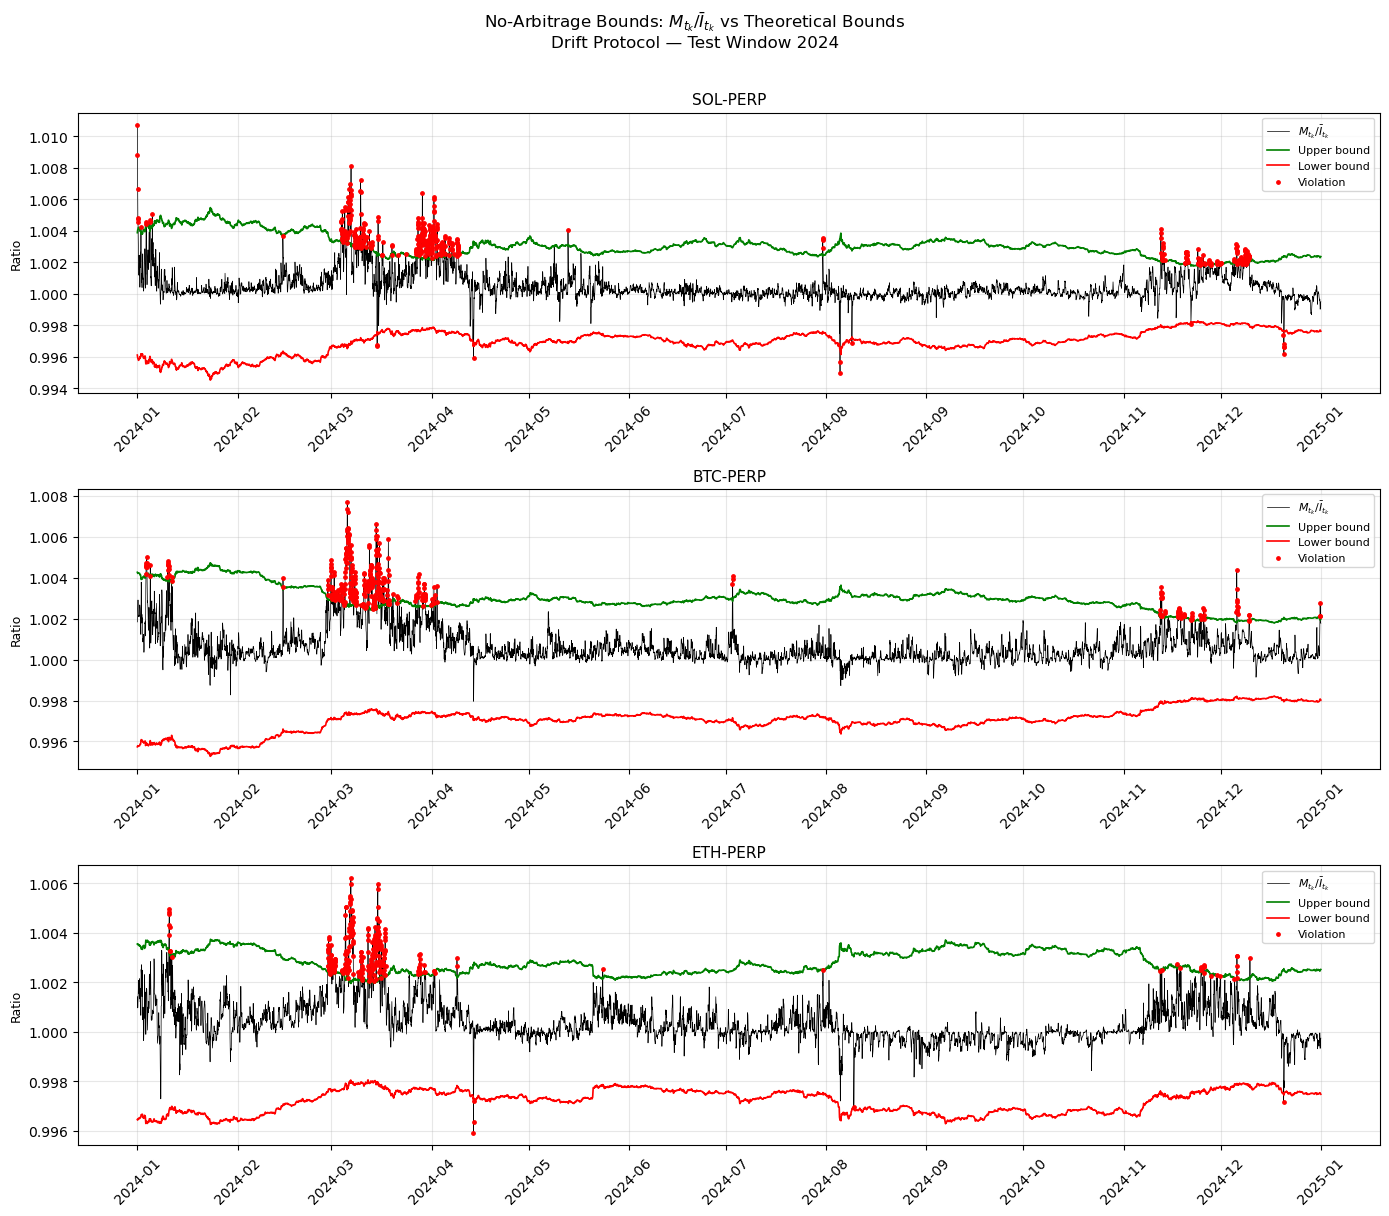

Figure saved.


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
markets = ["SOL-PERP", "BTC-PERP", "ETH-PERP"]

for ax, market in zip(axes, markets):
    grp = test_out[test_out["market"] == market].sort_values("timestamp")
    
    ax.plot(grp["timestamp"], grp["ratio"],
            color="black", linewidth=0.5, label="$M_{t_k}/\\bar{I}_{t_k}$")
    ax.plot(grp["timestamp"], grp["U_tk"],
            color="green", linewidth=1.2, linestyle="-", label="Upper bound")
    ax.plot(grp["timestamp"], grp["L_tk"],
            color="red", linewidth=1.2, linestyle="-", label="Lower bound")
    
    # shade violations
    viol = grp[grp["violation"]]
    ax.scatter(viol["timestamp"], viol["ratio"],
               color="red", s=6, zorder=5, label="Violation")
    
    ax.set_title(market, fontsize=11)
    ax.set_ylabel("Ratio", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "No-Arbitrage Bounds: $M_{t_k}/\\bar{I}_{t_k}$ vs Theoretical Bounds\n"
    "Drift Protocol — Test Window 2024",
    fontsize=12, y=1.01
)
plt.tight_layout()

FIGURES = Path.home() / "Desktop/Classes/Smirnov_Research Project/defi-perps/drift/analysis"
plt.savefig(FIGURES / "figure1_bounds_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [11]:
print("=" * 60)
print("ROBUSTNESS — Violation rates under different Gamma levels")
print("=" * 60)

for pct in [0.99, 0.95, 0.90]:
    gammas_pct = {}
    for market, grp in train.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        basis = (grp["mark_twap"] - grp["oracle_twap"]).abs()
        gammas_pct[market] = basis.quantile(pct)

    rows_pct = []
    for market, grp in test.groupby("market"):
        grp = grp.sort_values("timestamp").reset_index(drop=True)
        gamma = gammas_pct[market]
        gamma_norm = gamma / grp["oracle_twap"]
        funding    = grp["f_tk"].abs() * grp["rho_k"]
        L_tk = (1 - kappa_S) + funding - gamma_norm
        U_tk = (1 + kappa_S) - funding + gamma_norm
        grp["L_tk"]      = L_tk
        grp["U_tk"]      = U_tk
        grp["violation"] = (grp["ratio"] < L_tk) | (grp["ratio"] > U_tk)
        rows_pct.append(grp)

    out_pct = pd.concat(rows_pct, ignore_index=True)

    print(f"\nGamma = {int(pct*100)}th percentile:")
    for market, grp in out_pct.groupby("market"):
        g_val = gammas_pct[market]
        vrate = grp["violation"].mean() * 100
        print(f"  {market}: Gamma={g_val:.4f}  violation rate={vrate:.2f}%")

ROBUSTNESS — Violation rates under different Gamma levels

Gamma = 99th percentile:
  BTC-PERP: Gamma=176.2908  violation rate=4.55%
  ETH-PERP: Gamma=7.8162  violation rate=3.21%
  SOL-PERP: Gamma=0.4235  violation rate=5.02%

Gamma = 95th percentile:
  BTC-PERP: Gamma=88.4823  violation rate=14.47%
  ETH-PERP: Gamma=4.5683  violation rate=9.96%
  SOL-PERP: Gamma=0.1139  violation rate=23.38%

Gamma = 90th percentile:
  BTC-PERP: Gamma=51.8620  violation rate=24.71%
  ETH-PERP: Gamma=2.8476  violation rate=19.35%
  SOL-PERP: Gamma=0.0666  violation rate=32.06%


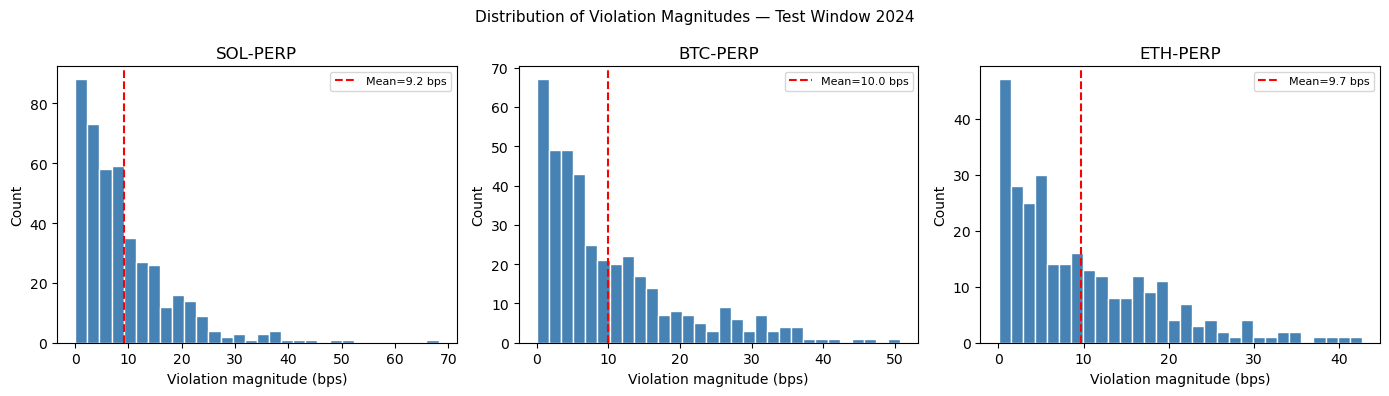

In [12]:
# Plot 2 — violation magnitude histogram
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, market in zip(axes, ["SOL-PERP", "BTC-PERP", "ETH-PERP"]):
    grp = test_out[test_out["market"] == market]
    viol_mag = np.where(
        grp["ratio"] < grp["L_tk"],
        grp["L_tk"] - grp["ratio"],
        np.where(grp["ratio"] > grp["U_tk"],
                 grp["ratio"] - grp["U_tk"], 0)
    )
    viol_mag = viol_mag[viol_mag > 0]
    ax.hist(viol_mag * 10000, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(market)
    ax.set_xlabel("Violation magnitude (bps)")
    ax.set_ylabel("Count")
    ax.axvline(np.mean(viol_mag * 10000), color="red",
               linestyle="--", label=f"Mean={np.mean(viol_mag*10000):.1f} bps")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Violation Magnitudes — Test Window 2024", fontsize=11)
plt.tight_layout()
FIGURES = Path.home() / "Desktop/Classes/Smirnov_Research Project/defi-perps/drift/analysis"
plt.savefig(FIGURES / "figure2_violation_magnitudes.png", dpi=150, bbox_inches="tight")
plt.show()

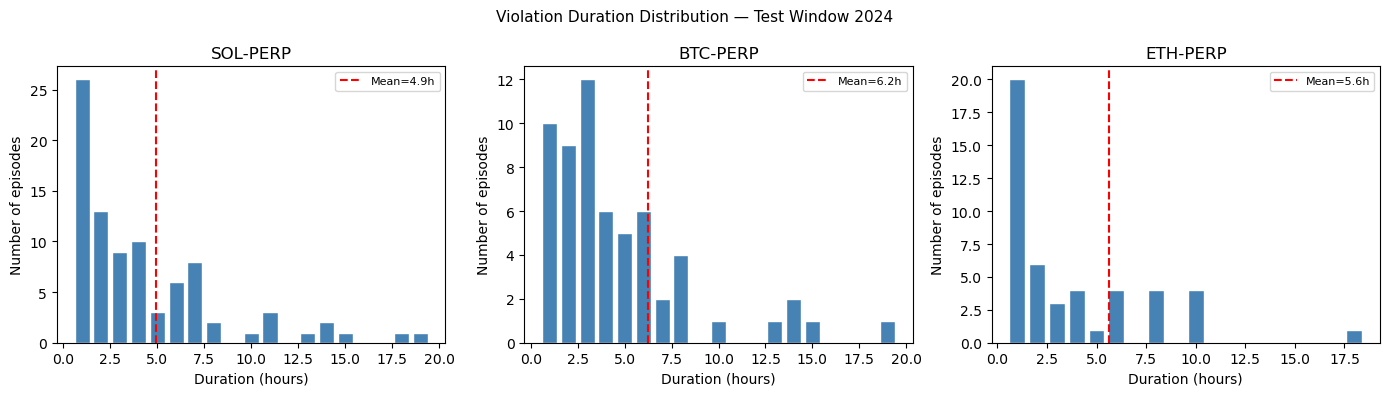

In [13]:
# Plot 3 — violation duration bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, market in zip(axes, ["SOL-PERP", "BTC-PERP", "ETH-PERP"]):
    grp = test_out[test_out["market"] == market].sort_values("timestamp")
    runs, dur = [], 0
    for v in grp["violation"]:
        if v:
            dur += 1
        elif dur > 0:
            runs.append(dur)
            dur = 0
    if dur > 0:
        runs.append(dur)

    runs = pd.Series(runs)
    dur_counts = runs.value_counts().sort_index()
    # cap display at 20 periods
    dur_counts = dur_counts[dur_counts.index <= 20]

    ax.bar(dur_counts.index, dur_counts.values, color="steelblue", edgecolor="white")
    ax.set_title(market)
    ax.set_xlabel("Duration (hours)")
    ax.set_ylabel("Number of episodes")
    ax.axvline(runs.mean(), color="red", linestyle="--",
               label=f"Mean={runs.mean():.1f}h")
    ax.legend(fontsize=8)

plt.suptitle("Violation Duration Distribution — Test Window 2024", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "figure3_violation_durations.png", dpi=150, bbox_inches="tight")
plt.show()

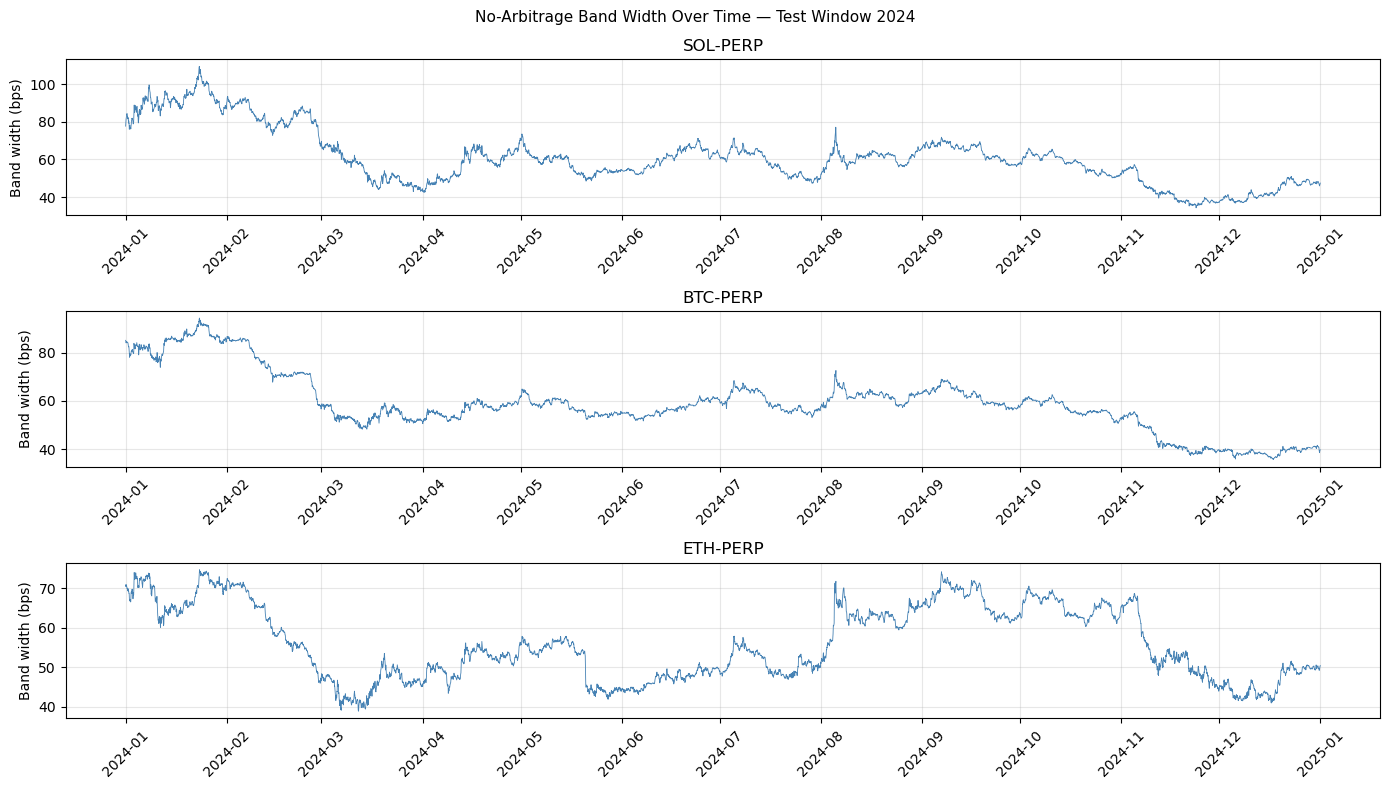

In [14]:
# Plot 4 — band width over time (shows bounds are dynamic)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for ax, market in zip(axes, ["SOL-PERP", "BTC-PERP", "ETH-PERP"]):
    grp = test_out[test_out["market"] == market].sort_values("timestamp")
    ax.plot(grp["timestamp"], grp["band_width"] * 10000,
            color="steelblue", linewidth=0.6)
    ax.set_title(market)
    ax.set_ylabel("Band width (bps)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle("No-Arbitrage Band Width Over Time — Test Window 2024", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "figure4_band_width.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("=" * 60)
print("BASIC TRADING STRATEGY — Mean reversion on bound violations")
print("=" * 60)

# Exit logic fix:
# Enter when ratio outside bounds
# Exit when ratio reverts to neutral zone: within NEUTRAL_BAND of 1.0
# This ensures the trade actually profits from reversion, not just
# barely crossing back inside the bound

NEUTRAL_BAND = 0.0010   # exit when ratio within 10 bps of 1.0

strategy_results = []

for market, grp in test_out.groupby("market"):
    grp = grp.sort_values("timestamp").reset_index(drop=True)

    position    = 0
    entry_ratio = None
    entry_idx   = None
    trades      = []

    for i in range(len(grp)):
        row   = grp.iloc[i]
        ratio = row["ratio"]
        L     = row["L_tk"]
        U     = row["U_tk"]

        if position == 0:
            if ratio > U:
                position    = -1        # short — perp overpriced
                entry_ratio = ratio
                entry_idx   = i
            elif ratio < L:
                position    = +1        # long — perp underpriced
                entry_ratio = ratio
                entry_idx   = i

        else:
            # exit when ratio reverts to neutral zone around 1.0
            neutral = abs(ratio - 1.0) < NEUTRAL_BAND
            # also force exit after 48 hours to avoid holding forever
            max_hold = (i - entry_idx) >= 48

            if neutral or max_hold:
                pnl_gross = position * (entry_ratio - ratio)
                pnl_net   = pnl_gross - 2 * kappa_S
                duration  = i - entry_idx
                exit_type = "neutral" if neutral else "max_hold"

                trades.append({
                    "entry_idx"  : entry_idx,
                    "exit_idx"   : i,
                    "position"   : position,
                    "entry_ratio": entry_ratio,
                    "exit_ratio" : ratio,
                    "pnl_gross"  : pnl_gross,
                    "pnl_net"    : pnl_net,
                    "duration"   : duration,
                    "exit_type"  : exit_type,
                })
                position    = 0
                entry_ratio = None

    trades_df = pd.DataFrame(trades)

    if trades_df.empty:
        print(f"\n{market}: no completed trades")
        continue

    n_trades   = len(trades_df)
    win_rate   = (trades_df["pnl_net"] > 0).mean()
    total_pnl  = trades_df["pnl_net"].sum()
    mean_pnl   = trades_df["pnl_net"].mean()
    mean_dur   = trades_df["duration"].mean()
    neutral_exits = (trades_df["exit_type"] == "neutral").sum()
    forced_exits  = (trades_df["exit_type"] == "max_hold").sum()
    sharpe = (trades_df["pnl_net"].mean() / trades_df["pnl_net"].std()
              if trades_df["pnl_net"].std() > 0 else 0)

    print(f"\n{market}:")
    print(f"  Trades completed  : {n_trades}")
    print(f"  Win rate          : {win_rate*100:.1f}%")
    print(f"  Mean PnL (net)    : {mean_pnl*10000:.2f} bps per trade")
    print(f"  Total PnL (net)   : {total_pnl*10000:.2f} bps")
    print(f"  Mean duration     : {mean_dur:.1f} hours")
    print(f"  Neutral exits     : {neutral_exits} ({neutral_exits/n_trades*100:.0f}%)")
    print(f"  Forced exits      : {forced_exits} ({forced_exits/n_trades*100:.0f}%)")
    print(f"  Sharpe proxy      : {sharpe:.2f}")

    strategy_results.append((market, trades_df))

BASIC TRADING STRATEGY — Mean reversion on bound violations

BTC-PERP:
  Trades completed  : 30
  Win rate          : 10.0%
  Mean PnL (net)    : -19.35 bps per trade
  Total PnL (net)   : -580.42 bps
  Mean duration     : 26.1 hours
  Neutral exits     : 21 (70%)
  Forced exits      : 9 (30%)
  Sharpe proxy      : -1.38

ETH-PERP:
  Trades completed  : 32
  Win rate          : 6.2%
  Mean PnL (net)    : -20.40 bps per trade
  Total PnL (net)   : -652.82 bps
  Mean duration     : 16.9 hours
  Neutral exits     : 29 (91%)
  Forced exits      : 3 (9%)
  Sharpe proxy      : -2.14

SOL-PERP:
  Trades completed  : 43
  Win rate          : 7.0%
  Mean PnL (net)    : -25.04 bps per trade
  Total PnL (net)   : -1076.90 bps
  Mean duration     : 21.2 hours
  Neutral exits     : 36 (84%)
  Forced exits      : 7 (16%)
  Sharpe proxy      : -1.15


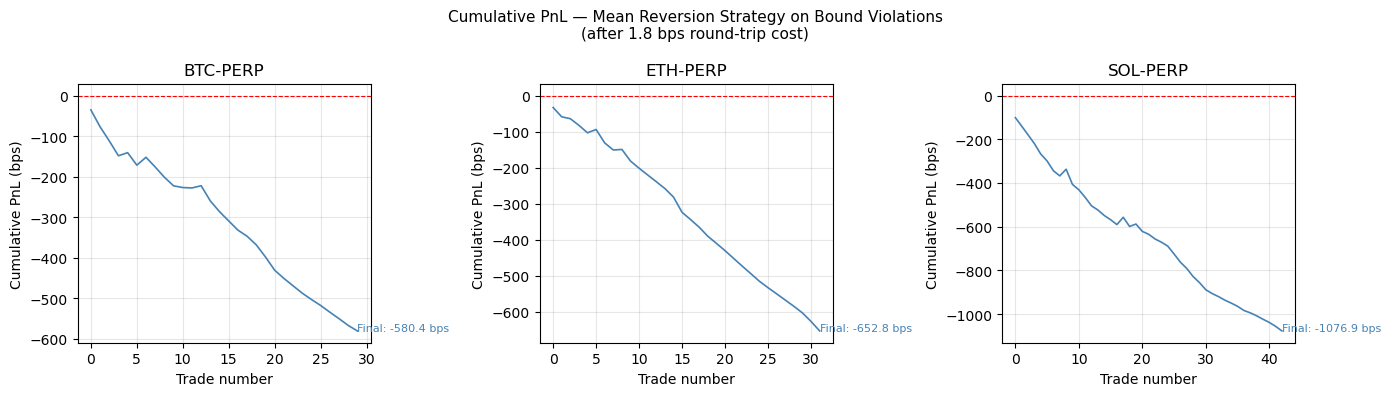

In [18]:
# Plot 5 — cumulative PnL of trading strategy
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (market, trades_df) in zip(axes, strategy_results):
    cum_pnl = trades_df["pnl_net"].cumsum() * 10000
    ax.plot(cum_pnl.values, color="steelblue", linewidth=1.2)
    ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_title(market)
    ax.set_xlabel("Trade number")
    ax.set_ylabel("Cumulative PnL (bps)")
    ax.grid(True, alpha=0.3)
    final = cum_pnl.iloc[-1]
    ax.annotate(f"Final: {final:.1f} bps",
                xy=(len(cum_pnl)-1, final),
                fontsize=8, color="steelblue")

plt.suptitle("Cumulative PnL — Mean Reversion Strategy on Bound Violations\n(after 1.8 bps round-trip cost)",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "figure5_strategy_pnl.png", dpi=150, bbox_inches="tight")
plt.show()